<a href="https://colab.research.google.com/github/shailu9/SimpleLinearRegression/blob/master/exploration/linearregressionfromscratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('./sample_data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

./sample_data/README.md
./sample_data/anscombe.json
./sample_data/Salary_dataset.csv
./sample_data/california_housing_train.csv
./sample_data/mnist_test.csv
./sample_data/mnist_train_small.csv
./sample_data/california_housing_test.csv


In [6]:
# Load the data
PATH_TO_DATASET = './sample_data/Salary_dataset.csv'
df = pd.read_csv(PATH_TO_DATASET)
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [7]:
# Checking the type of the data
type(df)

pandas.core.frame.DataFrame

In [8]:
df.columns

Index(['Unnamed: 0', 'YearsExperience', 'Salary'], dtype='object')

In [9]:
# Checking the correlation
df.corr()

,Unnamed: 0,YearsExperience,Salary
Unnamed: 0,1.000000,0.986460,0.960826
YearsExperience,0.986460,1.000000,0.978242
Salary,0.960826,0.978242,1.000000


In [10]:
# we can drop the column 0
df=df.drop('Unnamed: 0',axis='columns')

In [11]:
#Need plotting libs
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Text(0.5, 1.0, 'Scatter plot of df')

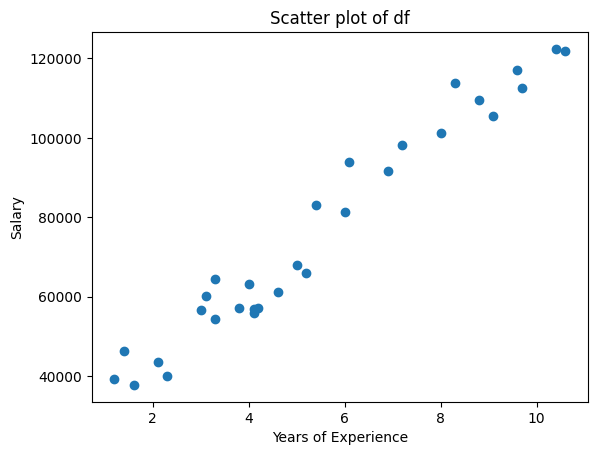

In [12]:
# Scatter plot
plt.scatter(df['YearsExperience'],df['Salary'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Scatter plot of df')

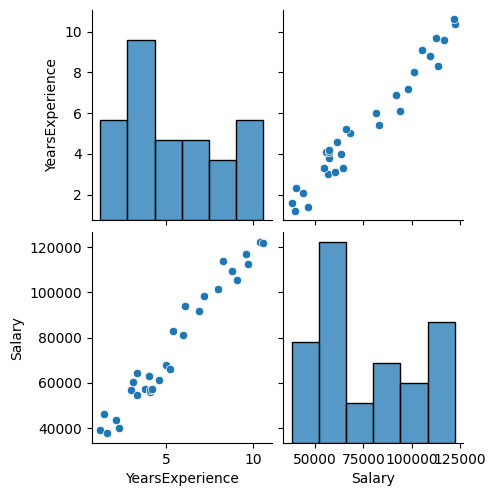

In [13]:
# Pair plot
sns.pairplot(df)

In [15]:
X=df['YearsExperience']
y=df['Salary']

type(X)
type(y)

pandas.core.series.Series

In [16]:
np.array(X).shape


(30,)

In [17]:
# need to convert to ndarray
X = np.array(X).reshape(len(X),1)
y = np.array(y).reshape(len(y),1)


np.array(X).shape


(30, 1)

In [18]:
# Creating train , test split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
# Check the shapes
print(f"Training Set Shapes => X_train: {X_train.shape}, y_train :{y_train.shape}")
print(f"Testing Set Shapes => X_test: {X_test.shape}, y_test :{y_test.shape}")



Training Set Shapes => X_train: (24, 1), y_train :(24, 1)
Testing Set Shapes => X_test: (6, 1), y_test :(6, 1)


In [26]:
import math, copy
# Funciton to calculate the cost

def compute_cost(x,y,w,b):
    m = x.shape[0] # number of training examples
    cost = 0

    for i in range(m):
        f_wb = w * x[i, 0] + b # Access scalar value
        cost = cost + (f_wb - y[i, 0])**2 # Access scalar value

    total_cost = cost * (1 / (2 * m))
    return total_cost

In [27]:
# Compute the gradient
# f(w,b) which also y^(y hat/ y predicated) = wX[i] + b
# In the need to find the w and b such that we want to minimize the loss funciton
# where loss function is => (1/2*m) Sumation {from m = 1 to n} (y^ - y)**2
# i.e  (1/2*m) Sumation {from m = 1 to n} (f(w,b) - y)**2
# to compute the min of loss function we will have to take partial derivates i.e. grandience
# of the loss funcion both w.r.t => w and b
# that what we are doing in this function
def compute_gradient (x,y,w,b):
   # Number of training examples
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = w * x[i, 0] + b # Access scalar value
        dj_dw_i = (f_wb - y[i, 0]) * x[i, 0] # Access scalar value
        dj_db_i = f_wb - y[i, 0] # Access scalar value
        dj_db += dj_db_i
        dj_dw += dj_dw_i
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

In [22]:
import math, copy
# Apply gradient descent
# We take the loss functio derivatives dj_dw and dj_db multiply the by learning rate,
# and then subtract them from w to get and b to get b respectively
# We repeat this until convergence or 10000 itrs
def gradient_descent(x,y,w_in,b_in,alpha,num_iters,cost_function,gradient_function):
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    p_history = []
    b = b_in
    w = w_in

    for i in range(num_iters):
        # Calculate the gradient and update the parameters using gradient_function
        dj_dw, dj_db = gradient_function(x, y, w , b)

        # Update Parameters using equation (3) above
        b = b - alpha * dj_db
        w = w - alpha * dj_dw

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion
            J_history.append( cost_function(x, y, w , b))
            p_history.append([w,b])
        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                  f"w: {w: 0.3e}, b:{b: 0.5e}")

    return w, b, J_history, p_history #return w and J,w history for graphing

In [28]:
# initialize hyper params
w_init =0
b_init =0

iterations = 10000
alpha = 1.0e-2

# run gradient descent and save params
w_final , b_final , J_hist , p_hist = gradient_descent(X_train,
                                                       y_train,
                                                       w_init,
                                                       b_init,
                                                       alpha,
                                                       iterations,compute_cost,compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final},{b_final})")


Iteration    0: Cost 1.29e+09  dj_dw: -4.706e+05, dj_db: -7.421e+04   w:  4.706e+03, b: 7.42086e+02
Iteration 1000: Cost 1.42e+07  dj_dw:  7.851e+01, dj_db: -5.351e+02   w:  9.773e+03, b: 2.19984e+04
Iteration 2000: Cost 1.36e+07  dj_dw:  8.325e+00, dj_db: -5.674e+01   w:  9.461e+03, b: 2.41276e+04
Iteration 3000: Cost 1.36e+07  dj_dw:  8.828e-01, dj_db: -6.016e+00   w:  9.428e+03, b: 2.43534e+04
Iteration 4000: Cost 1.36e+07  dj_dw:  9.361e-02, dj_db: -6.380e-01   w:  9.424e+03, b: 2.43774e+04
Iteration 5000: Cost 1.36e+07  dj_dw:  9.926e-03, dj_db: -6.765e-02   w:  9.424e+03, b: 2.43799e+04
Iteration 6000: Cost 1.36e+07  dj_dw:  1.053e-03, dj_db: -7.173e-03   w:  9.424e+03, b: 2.43802e+04
Iteration 7000: Cost 1.36e+07  dj_dw:  1.116e-04, dj_db: -7.606e-04   w:  9.424e+03, b: 2.43802e+04
Iteration 8000: Cost 1.36e+07  dj_dw:  1.184e-05, dj_db: -8.066e-05   w:  9.424e+03, b: 2.43802e+04
Iteration 9000: Cost 1.36e+07  dj_dw:  1.255e-06, dj_db: -8.553e-06   w:  9.424e+03, b: 2.43802e+04


In [29]:
def predict(x, w, b):
    return w * x + b

y_pred = predict(X_test, w_final, b_final)

print("Predictions on the test set:")
for i in range(len(X_test)):
    print(f"YearsExperience: {X_test[i][0]:.1f}, Actual Salary: {y_test[i][0]:.2f}, Predicted Salary: {y_pred[i][0]:.2f}")

Predictions on the test set:
YearsExperience: 9.7, Actual Salary: 112636.00, Predicted Salary: 115791.21
YearsExperience: 5.0, Actual Salary: 67939.00, Predicted Salary: 71499.28
YearsExperience: 8.3, Actual Salary: 113813.00, Predicted Salary: 102597.87
YearsExperience: 5.4, Actual Salary: 83089.00, Predicted Salary: 75268.80
YearsExperience: 3.3, Actual Salary: 64446.00, Predicted Salary: 55478.79
YearsExperience: 3.8, Actual Salary: 57190.00, Predicted Salary: 60190.70
